In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ../../..

/Users/dave/Library/CloudStorage/OneDrive-PolitecnicodiMilano/PhD/Repositories/DT-rse


## Evaluate Experiment Results

In this notebook, we test the adaptation phase of the OL routine with an offline dataset generated by the estimation routine. The idea is to validate the method and create a new faulty cluster from the outlier set.

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import seaborn as sns
from pathlib import Path
from scipy import signal
import plotly.graph_objects as go
from IPython.display import display, clear_output
import time

from ernesto.postprocessing.visualization import ernesto_plotter
from ernesto.adaptation.regime_shift.stats import *

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Set the basic style
# 'paper' context sets the base font size small (approx 8-9pt). 
# Scaling it by 1.3-1.5 usually matches standard 11pt/12pt thesis text nicely.
sns.set_context("paper", font_scale=1.4) 

# 2. Define the visual style
sns.set_style('whitegrid', {
    'grid.linestyle': '--', 
    'grid.alpha': 0.5,          # Lower alpha for less intrusive grid
    'grid.color': '.8',
    'axes.edgecolor': '0.15',
    'font.family': 'serif',     # Matches LaTeX default
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
})

# 3. Fine-tune Matplotlib params for Publication Quality
plt.rcParams.update({
    # Figure Size: 6x3.7 is close to the Golden Ratio for A4/Letter width
    'figure.figsize': (6.0, 3.75), 
    
    # Line width: Thicker for the main mean line
    'lines.linewidth': 2.0,     
    
    # Fonts: Ensure math looks like LaTeX
    'mathtext.fontset': 'cm',   # 'cm' = Computer Modern (LaTeX standard)
    'mathtext.rm': 'serif',
    
    # Axes and Ticks
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.bottom': True,       # Ensure ticks are visible
    'ytick.left': True,
    
    # Legend: Clean and readable
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.fancybox': False,   # Square corners match academic style better
    'legend.edgecolor': '0.8',
})

# 4. Color Palette: High contrast, colorblind safe
# Using 'bright' or 'colorblind' is best for distinguishing RL agents
plot_colors = sns.color_palette("colorblind")

In [4]:
ground_csv = "data/ground/online_learning/region_shift_validation_new.csv"
df_ground = pd.read_csv(ground_csv)

In [5]:
df_ground

,Voltage [V],Current [A],Time,Ambient Temperature [degC],Cell Temperature [degC]
0,3.9984,20.0101,8932.35,41.0096,41.2096
1,4.0000,19.9987,8932.45,41.0096,41.2096
2,4.0009,20.0101,8932.55,41.0063,41.2063
3,4.0019,20.0032,8932.65,41.0063,41.2063
4,4.0022,19.9987,8932.75,41.0063,41.2063
...,...,...,...,...,...
626316,4.0523,20.0009,71563.95,16.9698,17.1698
626317,4.0517,19.9872,71564.05,16.9627,17.1627
626318,4.0524,19.9964,71564.15,16.9627,17.1627
626319,4.0525,19.9849,71564.25,16.9540,17.1540


In [6]:
df_ground.max()

Voltage [V]                       4.1980
Current [A]                      20.2021
Time                          71564.3500
Ambient Temperature [degC]       43.9431
Cell Temperature [degC]          44.1431
dtype: float64

In [7]:
df_ground.min()

Voltage [V]                      3.5089
Current [A]                    -20.0782
Time                          8932.3500
Ambient Temperature [degC]      16.2235
Cell Temperature [degC]         16.4235
dtype: float64

In [28]:
dts = [i-j for i, j in zip(df_ground['Time'][1:], df_ground['Time'])]

In [34]:
df_ground[:20]

,Voltage [V],Current [A],Time,Ambient Temperature [degC],Cell Temperature [degC]
0,3.9984,20.0101,8932.35,41.0096,41.2096
1,4.0000,19.9987,8932.45,41.0096,41.2096
2,4.0009,20.0101,8932.55,41.0063,41.2063
3,4.0019,20.0032,8932.65,41.0063,41.2063
4,4.0022,19.9987,8932.75,41.0063,41.2063
5,4.0034,19.9964,8932.85,40.9396,41.1396
6,4.0043,19.9941,8932.95,40.9396,41.1396
7,4.0056,19.9941,8933.05,40.9396,41.1396
8,4.0061,20.0078,8933.15,40.9396,41.1396
9,4.0066,20.0101,8933.25,41.0706,41.2706


<Axes: >

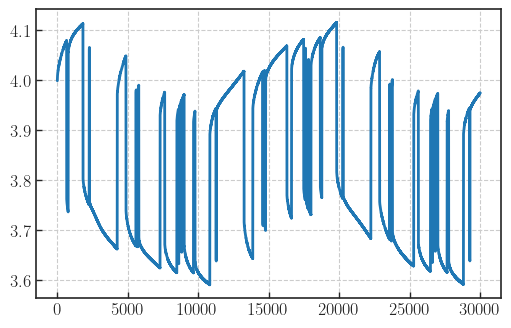

In [18]:
df_ground['Voltage [V]'][:30000].plot()

<Axes: >

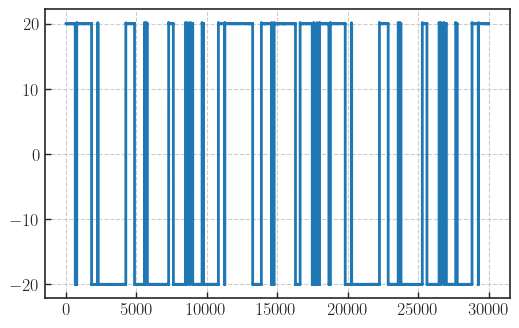

In [14]:
df_ground['Current [A]'][:30000].plot()

<Axes: >

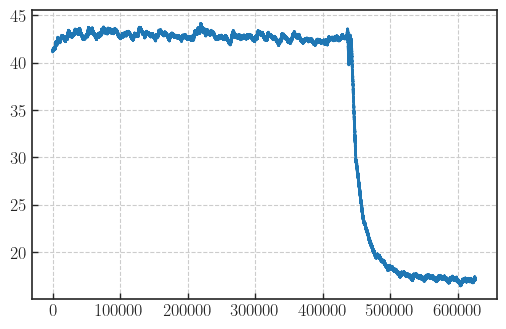

In [23]:
df_ground['Cell Temperature [degC]'][:].plot()

In [24]:
df_ground['Cell Temperature [degC]'].max()

np.float64(44.1431)

<Axes: >

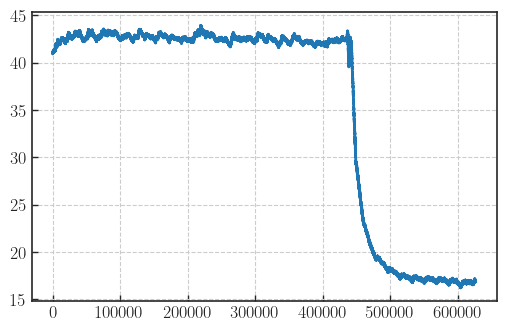

In [25]:
df_ground['Ambient Temperature [degC]'][:].plot()

In [26]:
df_ground['Ambient Temperature [degC]'].max()

np.float64(43.9431)

In [38]:
df_ground.to_csv("region_shift_validation_new.csv", index_label=False)

In [10]:
import numpy as np
from scipy.stats import skew, kurtosis
from ernesto.digital_twin.parameters.variables import instantiate_variables
from ernesto.digital_twin.battery_models.electrical.ecm_components import OCVGenerator

def loss_first_order_thevenin(params: list, 
                              input_batch: list,
                              init_state: dict, 
                              battery_config: dict, 
                              alpha: float,
                              beta: float,
                              ):
    
    # Read the parameters of electrical model
    r0, r1, c = params
    v_rc = 0   
    c_max = init_state['c_max']
    v = init_state['voltage']
    q = 0    
        
    # Parse the components that change within the model
    components = {}
    components['v_ocv'] = model['components']['v_ocv']
            
    # Instantiate the OCV generator
    init_components = instantiate_variables(components)
    ocv_gen = OCVGenerator(name='ocv', ocv_potential=init_components['v_ocv'])
    ocv_gen.reset_data()
    
    # SoC and temperature
    soc = init_state['soc']
    temp = init_state['temperature']
    ocv_gen.soc = soc
    ocv_gen.temp = temp
    
    estimated_v = []
    for k, sample in enumerate(input_batch[:-1]):
        # Normal operating step of the battery system.
        t_amb = sample['t_amb'] if 't_amb' in sample else init_state['t_amb']
        dt = input_batch[k+1]['time'] - sample['time']
                
        # Electrical model operation
        v_ocv = ocv_gen.ocv_potential
        
        # Passive convention
        i = -sample['current']
        
        # Compute V_r0 and V_rc
        v_r0 = r0 * i
        v_rc = (v_rc/dt + i/c) / (1/dt + 1 / (c * r1))
        i_rc = v_rc / r1

        # Compute V
        v = v_ocv - v_r0 - v_rc
        estimated_v.append(v)
        
        # If convention was 'passive', then we need to change the sign of the current
        i = sample['current']
        
        # Compute SoC with Coulomb counting
        soc = np.clip(soc + i / (c_max * 3600) * dt, a_min=0, a_max=1)
        
        # Ground temperature available
        if 'temperature' in sample:
            temp = sample['temperature']
        
        # Update the OCV generator
        ocv_gen.soc = soc
        ocv_gen.temp = temp
    
    # Compare the estimated voltage with the real one with the MSE
    estimated_v = np.array(estimated_v)
    true_voltage = np.array([sample['voltage'] for sample in input_batch[1:]])
    voltage_loss = np.sum((estimated_v - true_voltage) ** 2)
    regularization = alpha * np.sum(np.array(params) ** 2)
    return voltage_loss + regularization 


def scaled_loss(scaled_params, input_batch, init_state, battery_config, scale_factors, alpha, beta):
    # Unscale parameters
    params = np.array(scaled_params) / scale_factors
    return loss_first_order_thevenin(params, input_batch, init_state, battery_config, alpha, beta)

In [11]:
optim_dict = {
  'algorithm': "L-BFGS-B",
  'max_iter': 1000,
  'tol': None,
  'ftol': 0.000001,
  'gtol': 0.0001,
  'alpha': 0.,
  'beta': 0., #0.1
  'batch_size': 3000,
  'n_jobs': 4,
  'n_guesses': 4,
  'random_init': True,
}

search_bounds = {
    'r0': {
      'low': 0.001, #[1, 10]
      'high': 0.01
    },
    'r1': {
      'low': 0.001, #[1, 10]
      'high': 0.01
    },
    'c1': {
      'low': 5000. , #[1, 10]
      'high': 50000.
    }
}

scale_factors = {
    'r0': 1000,
    'r1': 1000,
    'c1': 0.0002,
}

In [12]:
scaled_bounds = [(low * s, high * s) for (low, high), s in zip(search_bounds, scale_factors)]  
args = (input_batch, init_state, self._battery_config, scale_factors, otpim_dict['alpha'], optim_dict['beta'])


guess = np.array([np.random.uniform(b[0], b[1]) for b in scaled_bounds]) 
results = minimize(loss, x0=guess, method=self._alg, bounds=scaled_bounds, options=optim_dict)

print("Estimation of new parameters:")
print("-----------------------------")
print(f"New theta: {results.x / self._scale_factors}, loss: {results.fun}")

TypeError: can't multiply sequence by non-int of type 'str'

In [ ]:
window_size = 3000
k = 0

init = {'voltage': 3.89722,
        'current': 0.,
        'temperature': 313.21,
        'soc': 0.7,
        'soh': 1.
        'c_max': 20,
        ''
       }

params = []

# Parse the components that change within the model
components = {}
components['v_ocv'] = model['components']['v_ocv']

# Instantiate the OCV generator
init_components = instantiate_variables(components)
ocv_gen = OCVGenerator(name='ocv', ocv_potential=init_components['v_ocv'])
ocv_gen.reset_data()

v = init['voltage']
temp = init['temperature']
soc = init['soc']

ocv_gen.soc = soc
ocv_gen.temp = temp

while k < len(df_ground):
    k_i = 0
    
    # Simulate until window_size
    while k_i < window_size and k + k_i < len(df_ground):
        
        
        k_i += 1
    
    # Read the parameters of electrical model
    r0, r1, c = params
    v_rc = 0   
    c_max = init_state['c_max']
    v = init_state['voltage'] 
    
    # SoC and temperature
    soc = init_state['soc']
    temp = init_state['temperature']
    ocv_gen.soc = soc
    ocv_gen.temp = temp
    
    estimated_v = []
    for k, sample in enumerate(input_batch[:-1]):
        # Normal operating step of the battery system.
        dt = input_batch[k+1]['time'] - sample['time']
                
        # Electrical model operation
        v_ocv = ocv_gen.ocv_potential
        
        # Passive convention
        i = -sample['current']
        
        # Compute V_r0 and V_rc
        v_r0 = r0 * i
        v_rc = (v_rc/dt + i/c) / (1/dt + 1 / (c * r1))
        i_rc = v_rc / r1

        # Compute V
        v = v_ocv - v_r0 - v_rc
        estimated_v.append(v)
        
        # If convention was 'passive', then we need to change the sign of the current
        i = sample['current']
        
        # Compute SoC with Coulomb counting
        soc = np.clip(soc + i / (c_max * 3600) * dt, a_min=0, a_max=1)
        
        # Ground temperature available
        temp = sample['temperature']
        
        # Update the OCV generator
        ocv_gen.soc = soc
        ocv_gen.temp = temp
    
    
    k += window_size
